# IPCA Illustration: ALS vs Grassmannian

Compare two IPCA estimators on simulated data:
- **ALS IPCA** — Alternating Least Squares (Kelly, Pruitt & Su 2019)
- **Grassmannian IPCA** — Riemannian Conjugate Gradient via pymanopt

Both solve the same profiled loss:
$$\min_{\Gamma:\,\Gamma'\Gamma=I_K} \frac{1}{T}\sum_t \min_f \|r_t - Z_t\Gamma f\|^2$$

In [1]:
import sys, os, time
os.chdir(os.path.join(os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()))

import numpy as np
import matplotlib.pyplot as plt

from src.generate.ipca import generate_ipca_data
from src.models.als_ipca import ALSIPCA
from src.models.grassmanian_ipca import GrassmannManifoldIPCAEstimator
from src.utils import subspace_error, recovery_report

## 1. Generate Synthetic Data

In [2]:
seed = 6890
np.random.seed(seed)

T = 63     # time periods
N = 500    # assets
m = 25     # characteristics
k = 5      # latent factors

data, truth = generate_ipca_data(
    T=T, N=N, m=m, k=k,
    include_intercept=False,
    seed=seed,
)

W_star = truth["W_star"]
rets, Z = data

print(f"Returns shape:          {rets.shape}  (T x N)")
print(f"Characteristics shape:  {Z.shape}  (T x N x m)")
print(f"True Gamma shape:       {W_star.shape}  (m x k)")

Returns shape:          (63, 500)  (T x N)
Characteristics shape:  (63, 500, 25)  (T x N x m)
True Gamma shape:       (25, 5)  (m x k)


## 2. Fit ALS IPCA

In [3]:
als = ALSIPCA(num_assets=N, num_fact=k, num_charact=m, win_len=T)

t0 = time.time()
Gamma_als, hist_als = als.fit(
    data, max_iter=5000, tol=1e-6,
    verbose=True, seed=seed, W_star=W_star,
)
als_time = time.time() - t0

print(f"\nWall time: {als_time:.2f}s")

Iteration    0: Objective = 1308.031553
Iteration    1: Objective = 188.392461, Gamma change = 0.60823067, Factor change = 0.00000000
Iteration    2: Objective = 185.716523, Gamma change = 0.05044241, Factor change = 4.15595758
Iteration    3: Objective = 185.715263, Gamma change = 0.00097644, Factor change = 0.03901022
Iteration    4: Objective = 185.715262, Gamma change = 0.00002829, Factor change = 0.00153550
Iteration    5: Objective = 185.715262, Gamma change = 0.00000093, Factor change = 0.00005055
Iteration    6: Objective = 185.715262, Gamma change = 0.00000003, Factor change = 0.00000160
Iteration    7: Objective = 185.715262, Gamma change = 0.00000000, Factor change = 0.00000005

Converged after 7 iterations
Initial objective: 1308.031553
Final objective:   185.715262
Reduction:         85.80%

Wall time: 2.10s


## 3. Fit Grassmannian IPCA (Riemannian CG)

In [4]:
grass = GrassmannManifoldIPCAEstimator(
    num_assets=N, num_fact=k, num_charact=m, win_len=T,
)

t0 = time.time()
Wopt, f_hat, hist_grass = grass.fit(
    data,
    optimizer="ConjugateGradient",
    max_iterations=200,
    verbosity=2,
    truth=truth,
)
grass_time = time.time() - t0

print(f"\nWall time: {grass_time:.2f}s")

Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
  1          +2.0028944080690651e+03    1.07157655e+03    
  2          +1.1433300521458427e+03    9.91558919e+02    
  3          +7.6904565869487146e+02    7.50357587e+02    
  4          +6.4389538240508068e+02    6.01553908e+02    
  5          +5.0966810720332916e+02    4.36029709e+02    
  6          +3.8743456840967627e+02    3.60559692e+02    
  7          +3.3978649855196903e+02    2.76304974e+02    
  8          +2.9582109469736776e+02    2.73884363e+02    
  9          +2.7440907965666378e+02    1.97054584e+02    
 10          +2.5912885350332192e+02    1.35902949e+02    
 11          +2.5126545367004763e+02    1.10501051e+02    
 12          +2.4263582913856703e+02    1.41984563e+02    
 13          +2.2373269060720509e+02    1.53352033e+02    
 14          +2.1341555543529054e+02    1.23179618e+02    
 15          +2.0539928712166341e+02    9.

## 4. Recovery Reports

In [5]:
print("ALS IPCA")
metrics_als = recovery_report(Gamma_als, truth)

print("\nGrassmannian IPCA")
metrics_grass = recovery_report(Wopt, truth)

ALS IPCA

=== Recovery Report ===
Grassmann distance:      0.056896
Principal angles (deg):  [2.3537, 1.6162, 1.1876, 0.8776, 0.5426]
Max principal angle:     2.353737 deg
RMS principal angle:     1.457878 deg

Grassmannian IPCA

=== Recovery Report ===
Grassmann distance:      0.056896
Principal angles (deg):  [2.3537, 1.6162, 1.1876, 0.8776, 0.5426]
Max principal angle:     2.353737 deg
RMS principal angle:     1.457879 deg


## 5. Comparison Plots

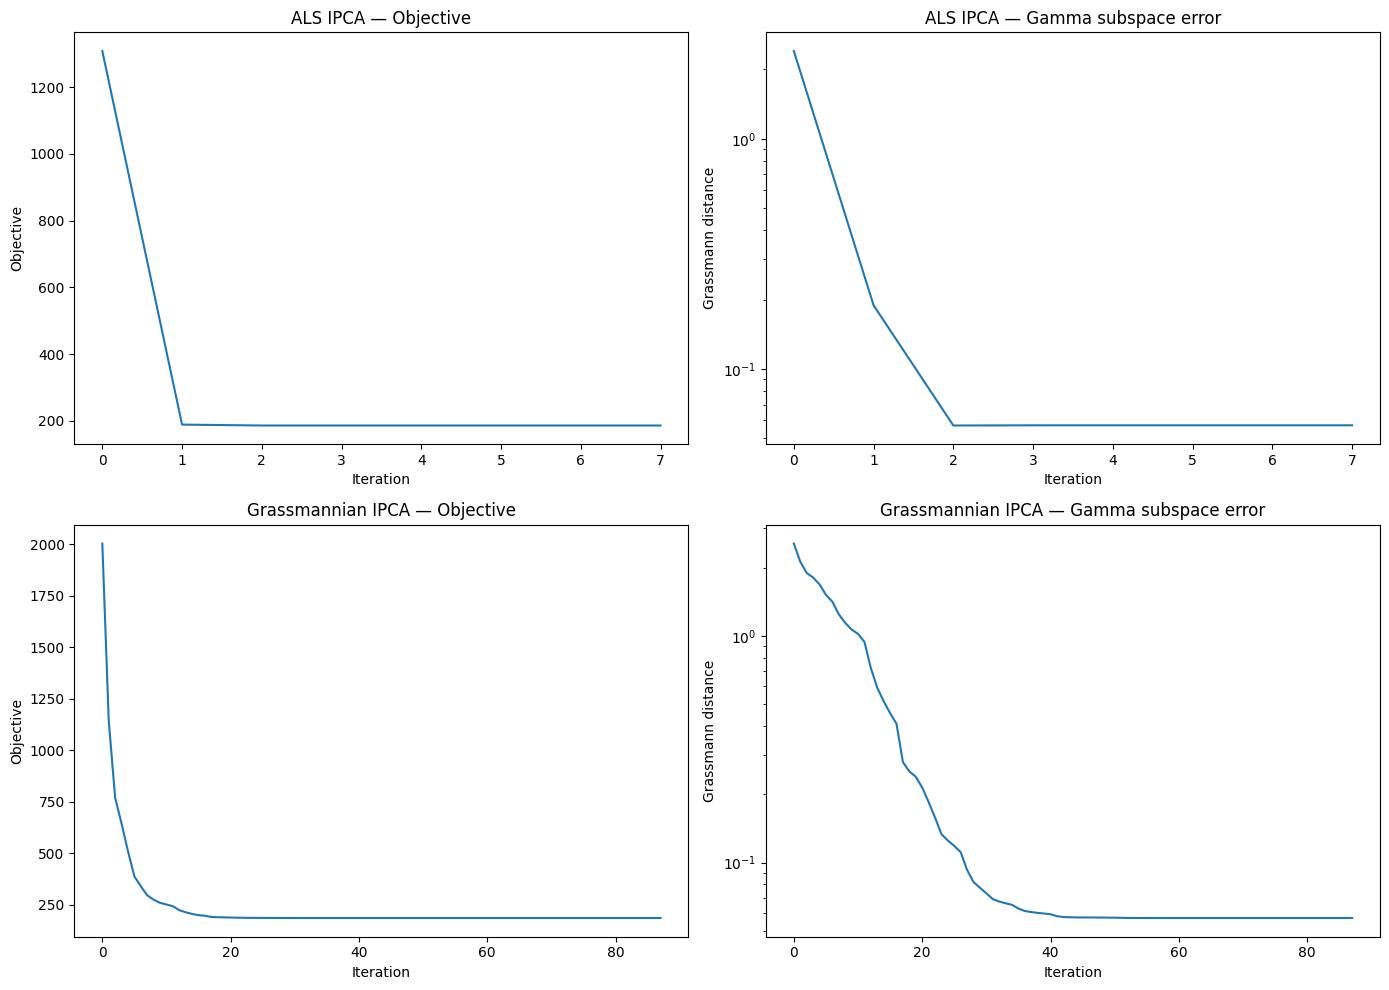

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ALS — objective
axes[0, 0].plot(hist_als)
axes[0, 0].set_xlabel("Iteration")
axes[0, 0].set_ylabel("Objective")
axes[0, 0].set_title("ALS IPCA — Objective")

# ALS — Gamma subspace error
axes[0, 1].plot(als.subspace_error_history)
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Grassmann distance")
axes[0, 1].set_title("ALS IPCA — Gamma subspace error")
axes[0, 1].set_yscale("log")

# Grassmannian — objective
axes[1, 0].plot(hist_grass)
axes[1, 0].set_xlabel("Iteration")
axes[1, 0].set_ylabel("Objective")
axes[1, 0].set_title("Grassmannian IPCA — Objective")

# Grassmannian — Gamma subspace error
axes[1, 1].plot(grass.gamma_error_history)
axes[1, 1].set_xlabel("Iteration")
axes[1, 1].set_ylabel("Grassmann distance")
axes[1, 1].set_title("Grassmannian IPCA — Gamma subspace error")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

## 6. Summary

In [7]:
print(f"{'':30s} {'ALS':>12s}  {'Grassmann':>12s}")
print("-" * 56)
print(f"{'Final objective':30s} {hist_als[-1]:12.4f}  {hist_grass[-1]:12.4f}")
print(f"{'Grassmann dist to W*':30s} {metrics_als['grassmann_dist']:12.6f}  {metrics_grass['grassmann_dist']:12.6f}")
print(f"{'Iterations':30s} {len(hist_als)-1:12d}  {len(hist_grass):12d}")
print(f"{'Wall time (s)':30s} {als_time:12.2f}  {grass_time:12.2f}")

                                        ALS     Grassmann
--------------------------------------------------------
Final objective                    185.7153      185.7153
Grassmann dist to W*               0.056896      0.056896
Iterations                                7            88
Wall time (s)                          2.10          2.00
